# PyTorch Primer

| Tutorial status | Details |
|---|---|
| **Course role** | Exercise-based technical primer for self-study and assignments |
| **Expected runtime** | 45-90 minutes when completing the exercises |
| **Hardware** | CPU is sufficient; CUDA is optional |
| **External data** | None |
| **Validation** | Core exercises; run cells as solutions are completed |


This is the exercise-based PyTorch primer for self-study and assignments. For a shorter, visual seminar introduction aimed at neuroscientists, use `01_pytorch_neuroscience_introduction.ipynb`.

We'll use Python and [PyTorch](https://pytorch.org/) for the labs in this course. This lab is to help you get up to speed. It will introduce:
- **Tensors**: PyTorch's equivalent of NumPy arrays, but with more bells and whistles for running on GPUs and supporting automatic differentiation.
- **Broadcasting and Fancy Indexing**: If you're coming from Matlab or NumPy, you probably know that you can avoid costly for-loops by broadcasting computation over dimensions of an array (here, tensor) and using fancy indexing tricks. 
- **Distributions**: PyTorch has an excellent library of distributions for sampling, evaluating log probabilities, and much more. 

We'll introduce these concepts in the context of the Poisson mixture model from class (c.f. [Probabilistic Modeling](../lectures/02_probabilistic_modeling.ipynb)).


In [1]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU model: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB" if torch.cuda.is_available() else "GPU memory: N/A")

PyTorch version: 2.3.1+cu118
CUDA available: True
GPU model: NVIDIA GeForce RTX 4060 Laptop GPU
GPU memory: 8.6 GB


## 1. Constructing Tensors

Tensors are PyTorch's equivalent of NumPy arrays. The PyTorch documentation already has a [great tutorial](https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html) on tensors. Rather than recreate the wheel, please start by reading that.

Once you've read through that, try using torch functions like `arange`, `reshape`, etc. to construct the following tensors.

### Problem 1.1

Construct the following tensor:

```
tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])
```

_Note: For this problems and the ones below, don't literally construct the tensor from the specified list. Use torch functions._

---

In [3]:
# Problem 1.1: Construct a 3x3 sequential tensor

# Solution: Create values 0-8 and reshape to 3x3
result_1_1 = torch.arange(9).reshape(3, 3)
print("Problem 1.1 - Sequential 3x3 tensor:")
print(result_1_1)

# Explanation:
# - torch.arange(9) creates [0, 1, 2, ..., 8]
# - .reshape(3, 3) reshapes it into a 3x3 matrix
#


Problem 1.1 - Sequential 3x3 tensor:
tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])


### Problem 1.2

Construct the following tensor:

```
tensor([[0, 3, 6],
        [1, 4, 7],
        [2, 5, 8]])
```

---

In [4]:
# Problem 1.2: Construct a transposed version of 1.1

# Solution 1: Use torch.t() for 2D tensors
result_1_2 = torch.t(result_1_1)
print("\nProblem 1.2 - Transposed tensor (method 1 - using torch.t()):")
print(result_1_2)

# Alternative Solution 2: Using reshape and permutation
# result_1_2_alt = torch.arange(9).reshape(3, 3).t()

# Explanation:
# - torch.t() transposes a 2D tensor (swaps rows and columns)
# - For a matrix A[i,j], transpose gives A[j,i]
#



Problem 1.2 - Transposed tensor (method 1 - using torch.t()):
tensor([[0, 3, 6],
        [1, 4, 7],
        [2, 5, 8]])


### Problem 1.3

Construct the following tensor:

```
tensor([0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4])
```

_Note: Here the sequence is repeated 3 times. Does your code support arbitrary numbers of repeats?_

---

In [5]:
# Problem 1.3: Construct repeated sequence [0,1,2,3,4] repeated 3 times

# Solution: Use torch.repeat to repeat a tensor
num_repeats = 3
result_1_3 = torch.arange(5).repeat(num_repeats)
print("\nProblem 1.3 - Repeated sequence:")
print(result_1_3)

# Explanation:
# - torch.arange(5) creates [0, 1, 2, 3, 4]
# - .repeat(n) repeats the entire tensor n times
# - Supports arbitrary number of repeats by changing num_repeats variable
#



Problem 1.3 - Repeated sequence:
tensor([0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4])


### Problem 1.4

Construct the following tensor:

```
tensor([[0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4]])
```

---

In [6]:
# Problem 1.4: Construct 5x3 matrix where each row is [0,1,2,3,4]

# Solution: Use torch.unsqueeze and repeat for broadcasting
# Create base sequence and repeat it to create multiple rows
base_sequence = torch.arange(5)
result_1_4 = base_sequence.unsqueeze(0).repeat(3, 1)
print("\nProblem 1.4 - Matrix with repeated rows:")
print(result_1_4)

# Explanation:
# - torch.arange(5) creates [0, 1, 2, 3, 4]
# - .unsqueeze(0) adds a new dimension at position 0, making it shape (1, 5)
# - .repeat(3, 1) repeats 3 times along dimension 0, 1 time along dimension 1
#



Problem 1.4 - Matrix with repeated rows:
tensor([[0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4]])


### Problem 1.5

Construct the following tensor:

```
tensor([[ 1., -2.,  0.,  0.],
        [-2.,  1., -2.,  0.],
        [ 0., -2.,  1., -2.],
        [ 0.,  0., -2.,  1.]])
```

---

In [7]:
# Problem 1.5: Construct a tridiagonal matrix

# Solution: Create a 4x4 identity matrix and add off-diagonals
n = 4
result_1_5 = torch.eye(n, dtype=torch.float32)
result_1_5 = result_1_5 - 2 * torch.diag(torch.ones(n-1), diagonal=1) 
result_1_5 = result_1_5 - 2 * torch.diag(torch.ones(n-1), diagonal=-1)
print("\nProblem 1.5 - Tridiagonal matrix:")
print(result_1_5)

# Explanation:
# - torch.diag(v, diagonal=k) creates a matrix with vector v on the k-th diagonal
#   * diagonal=0: main diagonal
#   * diagonal=1: first superdiagonal (above main)
#   * diagonal=-1: first subdiagonal (below main)
# - Subtract 2 times the superdiagonal and subdiagonal values
#



Problem 1.5 - Tridiagonal matrix:
tensor([[ 1., -2.,  0.,  0.],
        [-2.,  1., -2.,  0.],
        [ 0., -2.,  1., -2.],
        [ 0.,  0., -2.,  1.]])


### Problem 1.6

Construct the following tensor:

```
tensor([[[[0, 1, 2]]]])
```

---

In [8]:
# Problem 1.6: Construct nested 4D tensor [[[[0, 1, 2]]]]

# Solution: Use reshape or view to add extra dimensions
result_1_6 = torch.arange(3).reshape(1, 1, 1, 3)
print("\nProblem 1.6 - Nested 4D tensor:")
print(result_1_6)
print("Shape:", result_1_6.shape)

# Alternative solution using unsqueeze multiple times:
# result_1_6_alt = torch.arange(3).unsqueeze(0).unsqueeze(0).unsqueeze(0)

# Explanation:
# - torch.arange(3) creates [0, 1, 2]
# - .reshape(1, 1, 1, 3) adds three dimensions of size 1 before the final dimension
# - Result is a 4D tensor with shape (1, 1, 1, 3)
#



Problem 1.6 - Nested 4D tensor:
tensor([[[[0, 1, 2]]]])
Shape: torch.Size([1, 1, 1, 3])


## 2. Broadcasting and Fancy Indexing

Your life will be much easier and your code will be much faster once you get the hang of broadcasting and indexing. Start by reading the  [PyTorch documentation](https://pytorch.org/docs/stable/notes/broadcasting.html).

### Problem 2.1

Construct a tensor `X` where `X[i,j] = i + j` by broadcasting a sum of two 1-dimensional tensors.

For example, broadcast a sum to construct the following tensor, 

```
tensor([[0, 1, 2],
        [1, 2, 3],
        [2, 3, 4],
        [3, 4, 5]])
```        

---

In [9]:
# Problem 2.1: Construct tensor X where X[i,j] = i + j using broadcasting

# Solution: Create 1D tensors for rows and columns, then broadcast
rows = torch.arange(4).reshape(4, 1)  # Shape: (4, 1)
cols = torch.arange(3).reshape(1, 3)  # Shape: (1, 3)

# Broadcasting will expand both to shape (4, 3)
X = rows + cols
print("\nProblem 2.1 - Broadcasting sum:")
print(X)

# Explanation:
# - rows has shape (4, 1), cols has shape (1, 3)
# - PyTorch broadcasting expands both tensors to shape (4, 3) before adding
# - The resulting tensor X[i,j] = i + j for all i in [0,3] and j in [0,2]
#



Problem 2.1 - Broadcasting sum:
tensor([[0, 1, 2],
        [1, 2, 3],
        [2, 3, 4],
        [3, 4, 5]])


### Problem 2.2

Compute a distance matrix `D` where `D[i,j]` is the Euclidean distance between `X[i]` and `X[j]`, with

```
X = torch.arange(10, dtype=float).reshape(5, 2)
```

Your answer should be,

```
tensor([[ 0.0000,  2.8284,  5.6569,  8.4853, 11.3137],
        [ 2.8284,  0.0000,  2.8284,  5.6569,  8.4853],
        [ 5.6569,  2.8284,  0.0000,  2.8284,  5.6569],
        [ 8.4853,  5.6569,  2.8284,  0.0000,  2.8284],
        [11.3137,  8.4853,  5.6569,  2.8284,  0.0000]])
```        

---

In [10]:
X = torch.arange(10, dtype=float).reshape(5, 2)

# Problem 2.2: Compute Euclidean distance matrix using broadcasting

# Solution: Use broadcasting to compute ||X[i] - X[j]||^2 for all pairs (i,j)
# Expand X to shapes (5, 1, 2) and (1, 5, 2) for broadcasting
X_i = X.unsqueeze(1)  # Shape: (5, 1, 2)
X_j = X.unsqueeze(0)  # Shape: (1, 5, 2)

# Compute pairwise differences and Euclidean distance
diff = X_i - X_j  # Shape: (5, 5, 2)
D = torch.sqrt((diff ** 2).sum(dim=2))  # Shape: (5, 5)

print("\nProblem 2.2 - Euclidean distance matrix:")
print(D)

# Alternative one-liner using broadcasting:
# D_alt = torch.cdist(X, X)  # Uses built-in cdist function

# Explanation:
# - X has shape (5, 2), representing 5 points in 2D space
# - X.unsqueeze(1) adds dimension to get shape (5, 1, 2)
# - X.unsqueeze(0) adds dimension to get shape (1, 5, 2)
# - Broadcasting expands both to shape (5, 5, 2) during subtraction
# - (diff ** 2).sum(dim=2) computes squared distance for each pair
# - torch.sqrt() takes square root to get Euclidean distance
#



Problem 2.2 - Euclidean distance matrix:
tensor([[ 0.0000,  2.8284,  5.6569,  8.4853, 11.3137],
        [ 2.8284,  0.0000,  2.8284,  5.6569,  8.4853],
        [ 5.6569,  2.8284,  0.0000,  2.8284,  5.6569],
        [ 8.4853,  5.6569,  2.8284,  0.0000,  2.8284],
        [11.3137,  8.4853,  5.6569,  2.8284,  0.0000]], dtype=torch.float64)


### Problem 2.3 

Extract the submatrix of rows `[2,3]` and columns `[0,1,4]` of the tensor,
```
A = torch.arange(25).reshape(5, 5)
```

Your answer should be,
```
tensor([[10, 11, 14],
        [15, 16, 19]])
```

---

In [11]:
A = torch.arange(25).reshape(5, 5)

# Problem 2.3: Extract submatrix using fancy indexing

# Solution: Use advanced indexing with row and column indices
rows = torch.tensor([2, 3])
cols = torch.tensor([0, 1, 4])

# Method 1: Use advanced indexing with broadcasting
submatrix = A[rows.unsqueeze(1), cols]
print("\nProblem 2.3 - Submatrix extraction:")
print(submatrix)

# Explanation:
# - A has shape (5, 5)
# - rows has shape (2,), cols has shape (3,)
# - rows.unsqueeze(1) makes shape (2, 1), cols has shape (3,)
# - Broadcasting creates index pairs: (2,0), (2,1), (2,4), (3,0), (3,1), (3,4)
# - Result has shape (2, 3) containing A[i, j] for i in rows, j in cols
#



Problem 2.3 - Submatrix extraction:
tensor([[10, 11, 14],
        [15, 16, 19]])


### Problem 2.4

Create a binary mask matrix `M` of the same shape as `A` where `M[i,j]` is True if and only if `A[i,j]` is divisible by 7. Let

```
A = torch.arange(25).reshape(5, 5)
```

Your answer should be 

```
tensor([[ True, False, False, False, False],
        [False, False,  True, False, False],
        [False, False, False, False,  True],
        [False, False, False, False, False],
        [False,  True, False, False, False]])
```

---

In [12]:
A = torch.arange(25).reshape(5, 5)

# Problem 2.4: Create binary mask where M[i,j] is True if A[i,j] is divisible by 7

# Solution: Use modulo operator for divisibility check
M = (A % 7) == 0
print("\nProblem 2.4 - Binary mask for divisibility by 7:")
print(M)

# Explanation:
# - The modulo operator % computes the remainder after division
# - A % 7 gives the remainder when each element of A is divided by 7
# - (A % 7) == 0 creates a boolean tensor where True indicates divisibility by 7
# - Elements divisible by 7: 0, 7, 14, 21
#



Problem 2.4 - Binary mask for divisibility by 7:
tensor([[ True, False, False, False, False],
        [False, False,  True, False, False],
        [False, False, False, False,  True],
        [False, False, False, False, False],
        [False,  True, False, False, False]])


### Problem 2.5

Add one to the entries in `A` that are divisible by 7. After updating in place, `A` should be,

```
tensor([[ 1,  1,  2,  3,  4],
        [ 5,  6,  8,  8,  9],
        [10, 11, 12, 13, 15],
        [15, 16, 17, 18, 19],
        [20, 22, 22, 23, 24]])
```

---

In [13]:
# Problem 2.5: Add 1 to entries in A divisible by 7 (in-place modification)

# Recreate A for this problem
A = torch.arange(25).reshape(5, 5)

# Solution: Create mask and use it for in-place assignment
mask = (A % 7) == 0
A[mask] += 1

print("\nProblem 2.5 - In-place modification:")
print(A)

# Explanation:
# - Create boolean mask where True indicates values divisible by 7
# - Use mask for indexing: A[mask] selects all positions where mask is True
# - += 1 adds 1 to selected elements in-place
# - The operation modifies A directly without creating a copy
#



Problem 2.5 - In-place modification:
tensor([[ 1,  1,  2,  3,  4],
        [ 5,  6,  8,  8,  9],
        [10, 11, 12, 13, 15],
        [15, 16, 17, 18, 19],
        [20, 22, 22, 23, 24]])


## 3. Distributions

PyTorch has an excellent library of distributions in `torch.distributions`. Read the docs [here](https://pytorch.org/docs/stable/distributions.html).

We will use these distribution objects to construct and fit a Poisson mixture model.

### Problem 3.1

Draw 50 samples from a Poisson distribution with rate 10.

---

In [14]:
# Problem 3.1: Draw 50 samples from Poisson distribution with rate 10

# Solution: Create a Poisson distribution and sample from it
poisson_dist = dist.Poisson(rate=10.0)
samples_3_1 = poisson_dist.sample((50,))
print("\nProblem 3.1 - Poisson samples (rate=10):")
print(samples_3_1)
print("Mean of samples:", samples_3_1.mean().item())
print("Expected mean (rate):", 10.0)

# Explanation:
# - .sample((50,)) draws 50 independent samples from the distribution
#



Problem 3.1 - Poisson samples (rate=10):
tensor([19., 13., 12., 13., 11.,  7.,  6., 13., 16., 14., 12.,  6.,  9., 12.,
         9., 12., 13., 10.,  7.,  8.,  8., 15.,  8., 14., 16., 14., 11., 14.,
        12.,  8., 14.,  9.,  9.,  7.,  8., 10.,  9.,  8., 12., 15.,  8., 11.,
        12.,  7.,  5., 13.,  7.,  5.,  7.,  7.])
Mean of samples: 10.5
Expected mean (rate): 10.0


### Problem 3.2

One of the awesome thing about PyTorch distributions is that they support broadcasting too. 

Construct a matrix `P` where `P[i,j]` equals $\mathrm{Pois}(x=j; \lambda=i)$ for $i=0,\ldots,4$ and $j=0,\ldots,4$.

Your answer should be,
```
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3679, 0.3679, 0.1839, 0.0613, 0.0153],
        [0.1353, 0.2707, 0.2707, 0.1804, 0.0902],
        [0.0498, 0.1494, 0.2240, 0.2240, 0.1680],
        [0.0183, 0.0733, 0.1465, 0.1954, 0.1954]])
```

---

In [15]:

# Solution: Use broadcasting with PyTorch distributions
x_values = torch.arange(5, dtype=torch.float32)  # j values: 0, 1, 2, 3, 4
lambda_values = torch.arange(5, dtype=torch.float32)  # i values: 0, 1, 2, 3, 4

# Reshape for broadcasting: lambda has shape (5, 1), x has shape (1, 5)
lambda_expanded = lambda_values.unsqueeze(1)  # Shape: (5, 1)
x_expanded = x_values.unsqueeze(0)  # Shape: (1, 5)

# Create Poisson distributions with broadcasted rate parameter
poisson = dist.Poisson(rate=lambda_expanded)

# Evaluate log probability at x values and convert to probability
log_prob = poisson.log_prob(x_expanded)  # Shape: (5, 5)
P = torch.exp(log_prob)

print(P)

# Explanation:
# - Reshape to (1, 5) and (5, 1) respectively for broadcasting
# - Poisson distribution broadcasts rate across dimensions
# - log_prob(x) evaluates log P(X=x) for the Poisson distribution
# - exp(log_prob) converts log probability back to probability
#


tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3679, 0.3679, 0.1839, 0.0613, 0.0153],
        [0.1353, 0.2707, 0.2707, 0.1804, 0.0902],
        [0.0498, 0.1494, 0.2240, 0.2240, 0.1680],
        [0.0183, 0.0733, 0.1465, 0.1954, 0.1954]])


### Problem 3.3

Evaluate the log probability of the points `[1.5, 3., 4.2]` under a gamma distribution with shape (aka concentration) 2.0 and inverse scale (aka rate) 1.5.

Your answer should be,

```
tensor([-1.0336, -2.5905, -4.0540])
```

---

In [16]:
# Problem 3.3: Evaluate log probability under Gamma distribution

# Solution: Create Gamma distribution and evaluate log_prob
points = torch.tensor([1.5, 3.0, 4.2])
shape = 2.0  # concentration parameter
rate = 1.5   # inverse scale parameter

# Create Gamma distribution with shape and rate parameterization
# Note: PyTorch uses concentration (shape) and rate parameters
gamma_dist = dist.Gamma(concentration=shape, rate=rate)

# Evaluate log probability for each point
log_probs = gamma_dist.log_prob(points)
print("\nProblem 3.3 - Gamma log probabilities:")
print(log_probs)

# Explanation:
# - .log_prob(x) evaluates the log probability density at each point x
#



Problem 3.3 - Gamma log probabilities:
tensor([-1.0336, -2.5905, -4.0540])


### Problem 3.4

Draw 1000 samples from a Poisson mixture model,

$$
\begin{align*}
p(x) &= \frac{1}{2} \mathrm{Pois}(10.0) + \frac{1}{2} \mathrm{Pois}(2.0)
\end{align*}
$$

Use `matplotlib.pyplot.hist` to plot a normalized histogram of the samples.

---


Problem 3.4 - Poisson mixture model
Sample mean: 5.781000137329102
Expected mean: 0.5*10 + 0.5*2 = 6.0


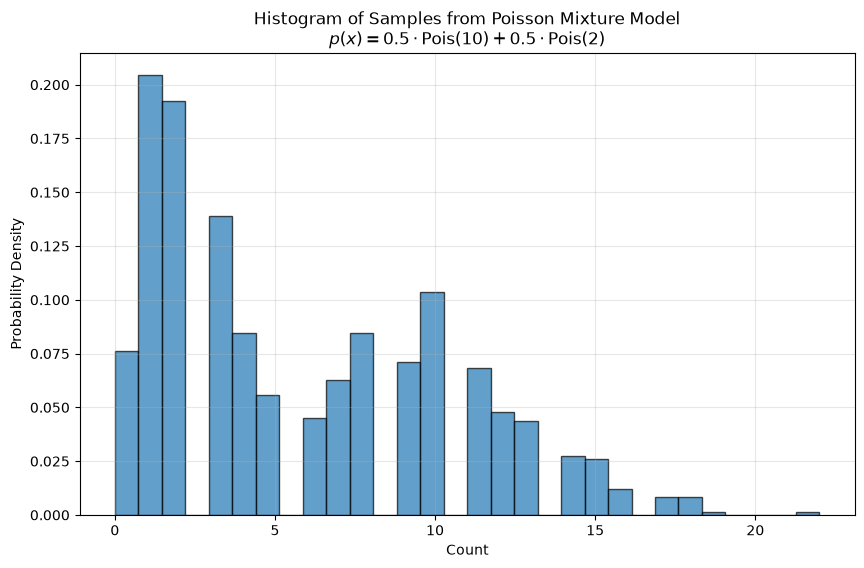

In [17]:
# Problem 3.4: Draw 1000 samples from Poisson mixture model and plot

# Solution: Create mixture distribution and sample, then plot
# p(x) = 0.5 * Pois(10.0) + 0.5 * Pois(2.0)

# Create component distributions
pois_10 = dist.Poisson(rate=10.0)
pois_2 = dist.Poisson(rate=2.0)

# Create mixture distribution using MixtureSameFamily
# Mixture with equal weights [0.5, 0.5]
mixture_dist = dist.MixtureSameFamily(
    mixture_distribution=dist.Categorical(probs=torch.tensor([0.5, 0.5])),
    component_distribution=dist.Poisson(rate=torch.tensor([10.0, 2.0]))
)

# Draw 1000 samples
data = mixture_dist.sample((1000,))
print("\nProblem 3.4 - Poisson mixture model")
print("Sample mean:", data.mean().item())
print("Expected mean: 0.5*10 + 0.5*2 = 6.0")

# Plot histogram of samples
plt.figure(figsize=(10, 6))
plt.hist(data.numpy(), bins=30, density=True, alpha=0.7, edgecolor='black')
plt.xlabel("Count")
plt.ylabel("Probability Density")
plt.title("Histogram of Samples from Poisson Mixture Model\n$p(x) = 0.5 \\cdot \\mathrm{Pois}(10) + 0.5 \\cdot \\mathrm{Pois}(2)$")
plt.grid(alpha=0.3)
plt.show()

# Explanation:
# - MixtureSameFamily combines a mixing distribution with component distributions
# - Categorical(probs=[0.5, 0.5]) defines cluster probabilities
# - component_distribution=Poisson([10.0, 2.0]) defines two Poisson components
# - .sample((1000,)) draws 1000 samples from the mixture
# - Each sample is drawn from one of two components with equal probability 0.5
# - Histogram shows bimodal distribution (peaks around 2 and 10)
#


## 4. MAP estimation

### Problem 4.1

Let `data` be the samples from above. Assume there are $K = 2$ clusters and the prior cluster probabilities $[\tfrac{1}{2}, \tfrac{1}{2}]$ are known. Complete the code below to perform MAP estimation.

---


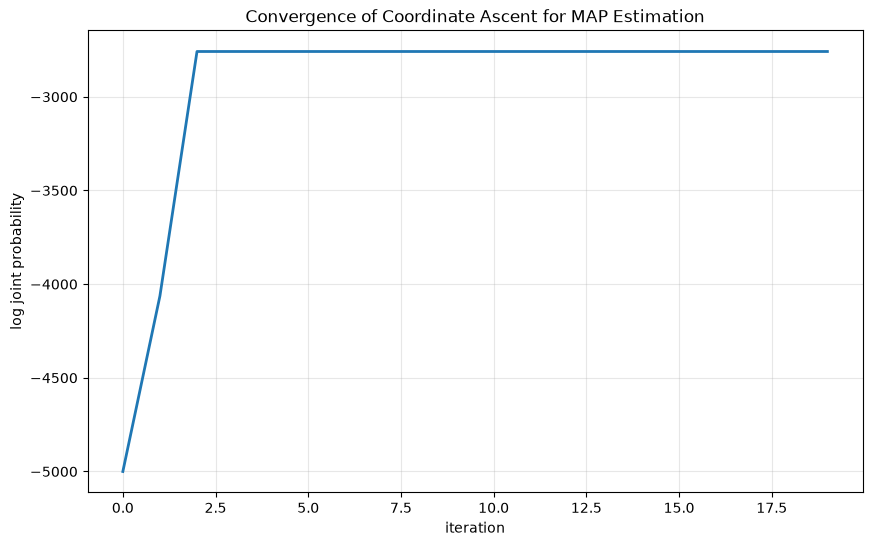

estimated rates: tensor([ 2.1537, 10.2227])
True mixture rates: [10.0, 2.0]


In [18]:
def update_assignments(data, rates, probs):
    """Update the cluster assignments ($z$) given the data, rates, 
    and cluster probabilities.

    Args:
        data: shape `(N,)` tensor of counts
        rates: shape `(K,)` tensor of nonnegative rates for each cluster.
        probs: shape `(K,)` tensor of cluster probabilities
        
    Returns:
        assignments: shape `(N,)` tensor of integer cluster assignments
    """
    # Solution: Assign each data point to the cluster with highest posterior probability
    
    # Expand dimensions for broadcasting
    # data shape: (N,) -> (N, 1)
    # rates shape: (K,) -> (1, K)
    data_expanded = data.unsqueeze(1)  # Shape: (N, 1)
    rates_expanded = rates.unsqueeze(0)  # Shape: (1, K)
    probs_expanded = probs.unsqueeze(0)  # Shape: (1, K)
    
    # Compute log likelihood for each data point under each cluster
    poisson_dist = dist.Poisson(rate=rates_expanded)
    log_likelihood = poisson_dist.log_prob(data_expanded)  # Shape: (N, K)
    
    # Add log cluster probability
    log_posterior = log_likelihood + torch.log(probs_expanded)  # Shape: (N, K)
    
    # Assign to cluster with highest log posterior
    assignments = torch.argmax(log_posterior, dim=1)  # Shape: (N,)
    
    return assignments

def update_rates(data, assignments, shape=1.0, inv_scale=1.0):
    """Update the rates for each cluster under a gamma prior.

    Args:
        data: shape `(N,)` tensor of counts
        assignments: shape `(N,)` tensor of integer cluster assignments
        shape: shape (aka concentration) of gamma prior. Defaults to 1.0.
        inv_scale: inverse scale (aka rate) of gamma prior. Defaults to 1.0.
        
    Returns:
        rates: shape `(K,)` tensor of updated rates for each cluster
    """
    # Solution: MAP estimation with Gamma prior
    # For Poisson likelihood with Gamma prior:
    # 
    #
    # where N_k = number of points assigned to cluster k
    
    K = int(assignments.max().item()) + 1  # Number of clusters
    rates = torch.zeros(K)
    
    for k in range(K):
        # Find points assigned to cluster k
        mask_k = (assignments == k)
        sum_x_k = data[mask_k].sum()
        n_k = mask_k.sum()
        
        # MAP estimate with Gamma(shape, inv_scale) prior
        rates[k] = (shape - 1 + sum_x_k) / (inv_scale + n_k)
    
    return rates
    

def log_joint(data, assignments, rates, probs, shape=1.0, inv_scale=1.0):
    """Compute the log joint probability under the mixture model.

    Args:
        data: shape `(N,)` tensor of counts
        assignments: shape `(N,)` tensor of integer cluster assignments
        rates: shape `(K,)` tensor of updated rates for each cluster
        probs: shape `(K,)` tensor of cluster probabilities
        shape: shape (aka concentration) of gamma prior. Defaults to 1.0.
        inv_scale: inverse scale (aka rate) of gamma prior. Defaults to 1.0.
        
    Returns:
        lp: scalar log joint probability under the mixture model
    """
    
    # Select the component rate assigned to each observation.
    assigned_rates = rates[assignments]
    poisson_dist = dist.Poisson(rate=assigned_rates)
    log_likelihood = poisson_dist.log_prob(data).sum()
    
    log_assignments = torch.log(probs[assignments]).sum()
    
    gamma_prior = dist.Gamma(concentration=torch.tensor(shape), 
                            rate=torch.tensor(inv_scale))
    log_prior = gamma_prior.log_prob(rates).sum()
    
    lp = log_likelihood + log_assignments + log_prior
    
    return lp
    
# Run coordinate ascent for some number of iterations, starting
# with random cluster assignments
probs = torch.ones(2) / 2.0
assignments = torch.randint(0, 2, data.shape)
rates = 10 * torch.rand(2)

lps = []
for i in range(20):
    lps.append(log_joint(data, assignments, rates, probs))
    rates = update_rates(data, assignments)
    assignments = update_assignments(data, rates, probs)
    
plt.figure(figsize=(10, 6))
plt.plot(lps, linewidth=2)
plt.xlabel("iteration")
plt.ylabel("log joint probability")
plt.title("Convergence of Coordinate Ascent for MAP Estimation")
plt.grid(alpha=0.3)
plt.show()

print("estimated rates:", rates)
print("True mixture rates: [10.0, 2.0]")


### Problem 4.2 (Bonus)

Now consider a more general model in which 

$$
z_n \sim \mathrm{Cat}(\boldsymbol{\pi})
$$

where the prior cluster probabilities $\boldsymbol{\pi}$ are unknown. (Above, we assumed they were known to be $\boldsymbol{\pi} = [\tfrac{1}{2}, \tfrac{1}{2}]$.) Derive and implement a coordinate ascent algorithm for MAP estimation of $\mathbf{z}_{\mathsf{MAP}}$, $\boldsymbol{\lambda}_{\mathsf{MAP}}$, and $\boldsymbol{\pi}_{\mathsf{MAP}}$.



Problem 4.2 (Bonus) - MAP estimation with unknown pi


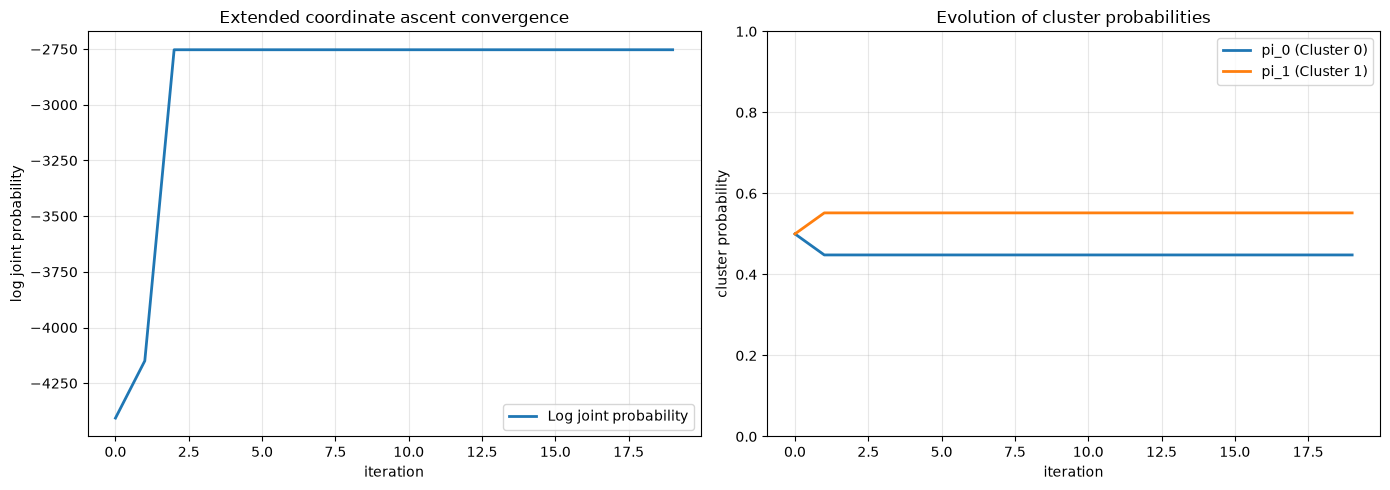


Final Results:
Estimated rates: lambda = tensor([10.2227,  2.1537])
Estimated probs: pi = tensor([0.4481, 0.5519])
True mixture rates: [10.0, 2.0]
True mixture probs: [0.5, 0.5]


In [19]:
# Problem 4.2 (Bonus): Learn cluster probabilities pi along with rates lambda and assignments z

# Solution: Extend coordinate ascent to include a Dirichlet prior over pi.
# The probability update uses the number of points assigned to each cluster.

def update_probs_bonus(assignments, alpha_dir=1.0):
    """Update cluster probabilities using a symmetric Dirichlet prior.

    Args:
        assignments: shape `(N,)` tensor of integer cluster assignments.
        alpha_dir: concentration parameter of the Dirichlet prior. Defaults to 1.0.

    Returns:
        probs: shape `(K,)` tensor of updated cluster probabilities.
    """
    K = int(assignments.max().item()) + 1  # Number of clusters
    N = len(assignments)

    # Count points in each cluster.
    counts = torch.zeros(K)
    for k in range(K):
        counts[k] = (assignments == k).sum()

    # MAP-style smoothed estimate for the mixture weights.
    probs = (alpha_dir + counts) / (K * alpha_dir + N)

    return probs

# Run extended coordinate ascent with learned cluster probabilities.
print("\n" + "="*60)
print("Problem 4.2 (Bonus) - MAP estimation with unknown pi")
print("="*60)

# Initialize parameters.
assignments_bonus = torch.randint(0, 2, data.shape)
rates_bonus = 10 * torch.rand(2)
probs_bonus = torch.ones(2) / 2.0  # Start with uniform probabilities.

lps_bonus = []
probs_history = []

for i in range(20):
    lps_bonus.append(log_joint(data, assignments_bonus, rates_bonus, probs_bonus))
    probs_history.append(probs_bonus.clone())

    # Update rates, assignments, and mixture probabilities.
    rates_bonus = update_rates(data, assignments_bonus)
    assignments_bonus = update_assignments(data, rates_bonus, probs_bonus)
    probs_bonus = update_probs_bonus(assignments_bonus)

# Plot convergence.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot log joint probability.
axes[0].plot(lps_bonus, linewidth=2, label='Log joint probability')
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("log joint probability")
axes[0].set_title("Extended coordinate ascent convergence")
axes[0].grid(alpha=0.3)
axes[0].legend()

# Plot evolution of cluster probabilities.
probs_history_array = torch.stack(probs_history).numpy()
axes[1].plot(probs_history_array[:, 0], linewidth=2, label='pi_0 (Cluster 0)')
axes[1].plot(probs_history_array[:, 1], linewidth=2, label='pi_1 (Cluster 1)')
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("cluster probability")
axes[1].set_title("Evolution of cluster probabilities")
axes[1].grid(alpha=0.3)
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\nFinal Results:")
print(f"Estimated rates: lambda = {rates_bonus}")
print(f"Estimated probs: pi = {probs_bonus}")
print("True mixture rates: [10.0, 2.0]")
print("True mixture probs: [0.5, 0.5]")

# Explanation:
# This bonus problem extends MAP estimation to learn mixture weights as well.
# Compared with Problem 4.1, the main loop now updates pi after z and lambda.
# The Dirichlet prior smooths empirical cluster proportions with pseudocounts.
# The algorithm jointly optimizes hard assignments z, Poisson rates lambda,
# and cluster probabilities pi.
